In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from pathlib import Path

json_path = Path("ceo_answers_best5.json")
if not json_path.exists():
    json_path = Path("evals/e2e/ceo_answers_best5.json")

data = pd.read_json(json_path)

In [9]:
data['tweak'] = data['variant'].apply(lambda x: x.get('tweak'))
data = data.drop(columns=['schema_version','run_id','recorded_at'])
data['query'] = data['task'].apply(lambda x: x.get('query'))
data['total_ms'] = data['metrics'].apply(lambda x: x.get('total_ms'))
data['effort'] = data['variant'].apply(lambda x: x.get('effort'))

In [14]:
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

flat = pd.DataFrame(
    {
        "task_id": data["task"].apply(lambda x: x.get("id")),
        "query": data["task"].apply(lambda x: x.get("query")),
        "category": data["task"].apply(lambda x: x.get("category")),
        "difficulty": data["task"].apply(lambda x: x.get("difficulty")),
        "tweak": data["variant"].apply(lambda x: x.get("tweak")),
        "mode": data["variant"].apply(lambda x: x.get("effort")),
        "repetition": data["variant"].apply(lambda x: x.get("repetition")),
        "time_ms": data["metrics"].apply(lambda x: x.get("total_ms")),
        "tokens": data["metrics"].apply(lambda x: x.get("tokens", {}).get("total_tokens")),
        "input_tokens": data["metrics"].apply(lambda x: x.get("tokens", {}).get("input_tokens")),
        "output_tokens": data["metrics"].apply(lambda x: x.get("tokens", {}).get("output_tokens")),
    }
)

flat["time_s"] = flat["time_ms"] / 1000

summary = pd.DataFrame(
    {
        "runs": [len(flat)],
        "unique_tweaks": [flat["tweak"].nunique()],
        "unique_modes": [flat["mode"].nunique()],
        "missing_token_rows": [flat["tokens"].isna().sum()],
        "avg_time_ms": [flat["time_ms"].mean()],
        "avg_tokens": [flat["tokens"].mean()],
    }
)

display(summary.round(2))
display(
    flat.groupby("tweak", dropna=False)
    .agg(
        runs=("task_id", "size"),
        avg_time_ms=("time_ms", "mean"),
        median_time_ms=("time_ms", "median"),
        avg_tokens=("tokens", "mean"),
        median_tokens=("tokens", "median"),
    )
    .sort_values("avg_time_ms", ascending=False)
    .round(2)
)

display(
    flat.groupby("mode", dropna=False)
    .agg(
        runs=("task_id", "size"),
        avg_time_ms=("time_ms", "mean"),
        median_time_ms=("time_ms", "median"),
        avg_tokens=("tokens", "mean"),
        median_tokens=("tokens", "median"),
    )
    .sort_values("avg_time_ms", ascending=False)
    .round(2)
)

,runs,unique_tweaks,unique_modes,missing_token_rows,avg_time_ms,avg_tokens
0,27,6,2,3,102727.03,24159.38


,runs,avg_time_ms,median_time_ms,avg_tokens,median_tokens
tweak,,,,,
explicit_planning,5,113122.04,96546.19,32641.60,22201.0
tight_budget,5,109960.48,71061.56,16748.00,14218.5
reflection,5,109450.88,76483.16,24372.20,19447.0
Verification-first,5,106811.79,60719.66,17667.33,18972.0
cot_n_shot,5,94320.82,83651.63,29796.40,22846.0
normal,2,52649.80,52649.80,12890.00,12890.0


,runs,avg_time_ms,median_time_ms,avg_tokens,median_tokens
mode,,,,,
mid,21,114723.41,96546.19,28586.17,22708.0
flash,6,60739.68,58951.77,10879.00,10708.0


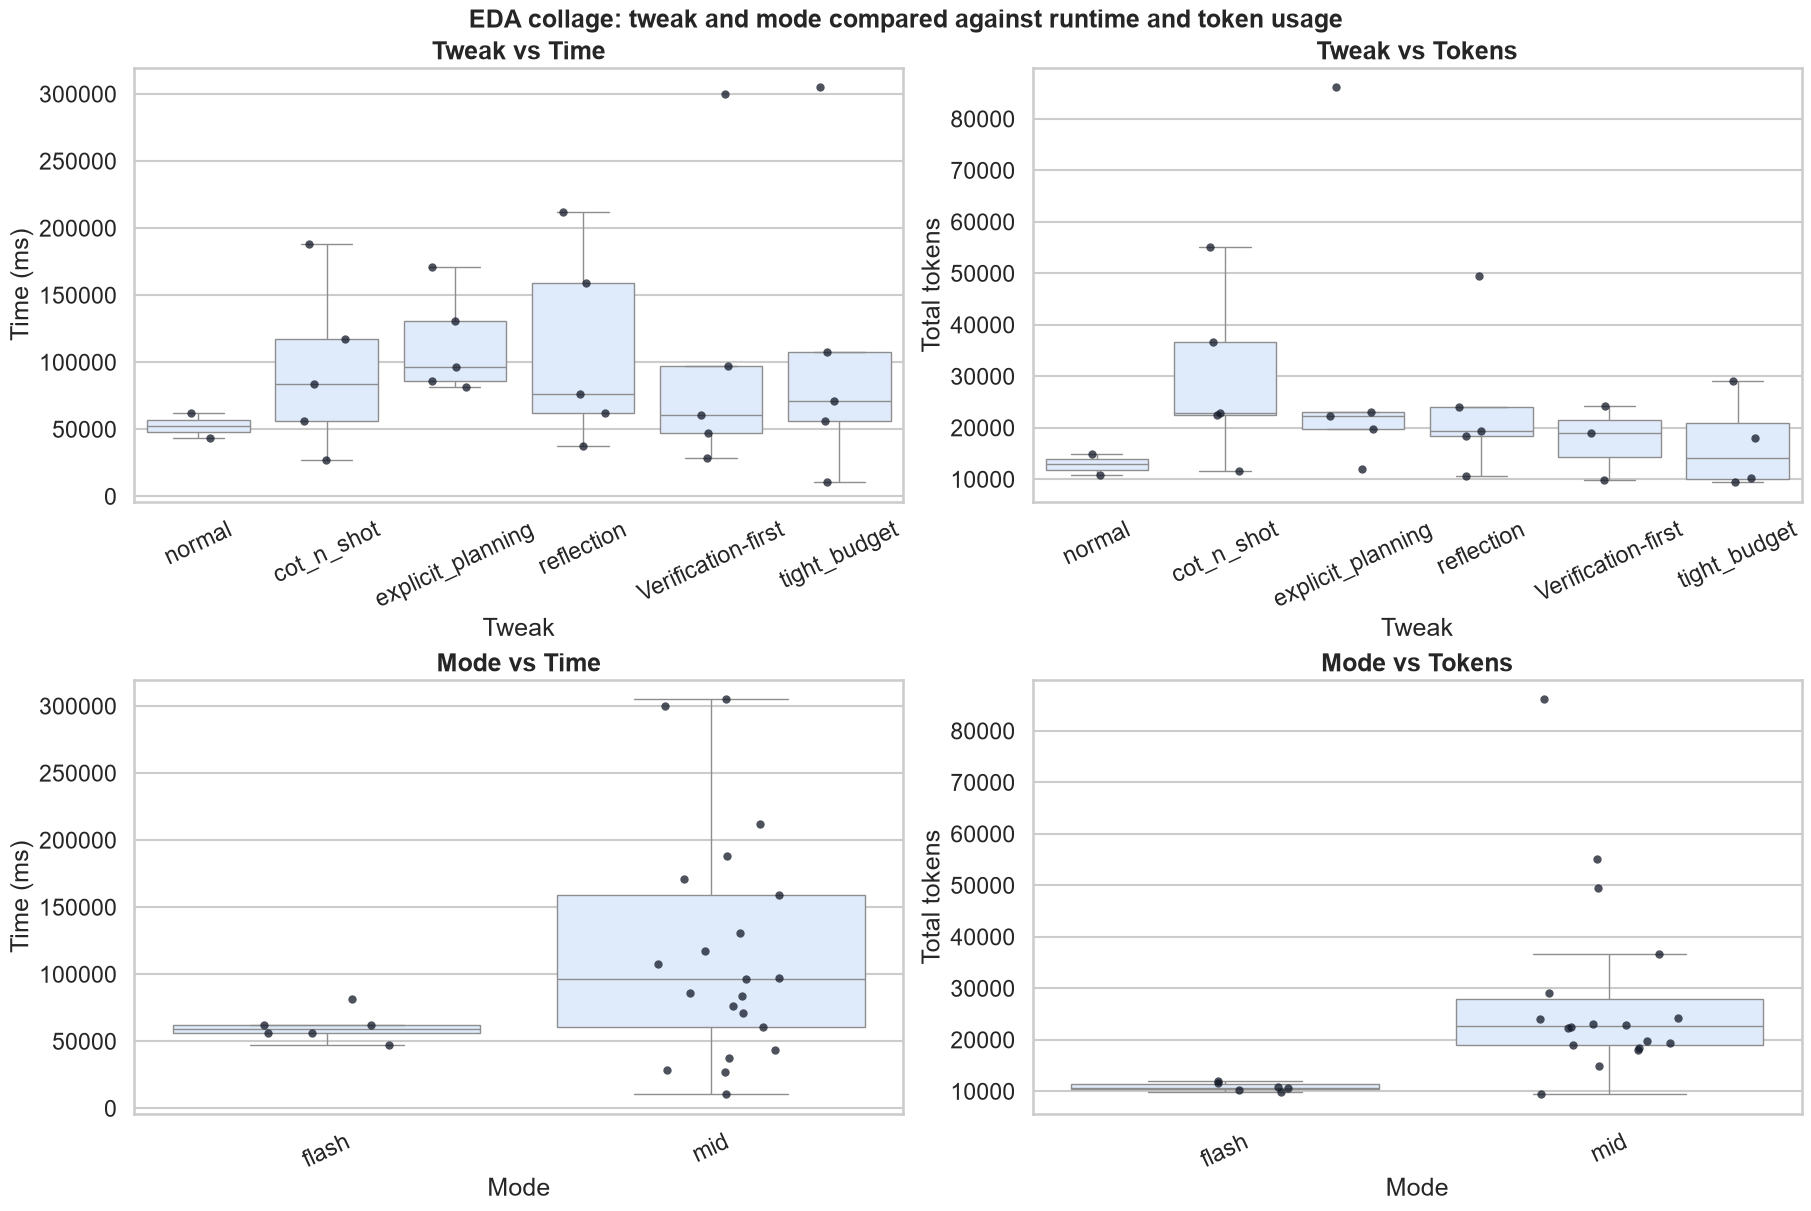

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

chart_specs = [
    ("tweak", "time_ms", "Tweak vs Time"),
    ("tweak", "tokens", "Tweak vs Tokens"),
    ("mode", "time_ms", "Mode vs Time"),
    ("mode", "tokens", "Mode vs Tokens"),
]

for ax, (x_col, y_col, title) in zip(axes.flat, chart_specs):
    sns.boxplot(
        data=flat,
        x=x_col,
        y=y_col,
        ax=ax,
        color="#dbeafe",
        showfliers=False,
    )
    sns.stripplot(
        data=flat,
        x=x_col,
        y=y_col,
        ax=ax,
        color="#111827",
        alpha=0.75,
        jitter=0.18,
        size=6,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x_col.capitalize())
    ax.tick_params(axis="x", rotation=25)
    if y_col == "time_ms":
        ax.set_ylabel("Time (ms)")
    else:
        ax.set_ylabel("Total tokens")

fig.suptitle(
    "EDA collage: tweak and mode compared against runtime and token usage",
    fontsize=18,
    fontweight="bold",
)
output_path = Path("/home/electron/Documents/GitHub/Co_Founder/docs/eda.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, bbox_inches="tight", dpi=200)
plt.show()